<a href="https://colab.research.google.com/github/erre-x-erre/Metodos_Numericos_I/blob/main/M%C3%A9todo%20de%20Bisecci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#***<font color="green">"MÉTODO DE BISECCIÓN"</font>***

El método de bisección esta basado en el siguiente teorema.

***"Teorema del Valor Intermedio"***.

Si $f\in C[a,b]$ y $K$ es cualquier número entre $f(a)$ y $f(b)$, entonces existe un número $c$ en $(a,b)$ para el cual $f(c)=K$.

Es decir, si $f$ es contunia en un intervalo $[a,b]$, $f(a)$ y $f(b)$ difieren en signo, entonces existe $c$ para el cual $f(c)=0$.

El método consiste en suponer que $f$ es continua, con $f(a)$ y $f(b)$ de signos opuestos, gracias al teorema sabemos que existe un número $p$ para el cual $f(p)=0$ es decir, existe una raíz.

Para comenzar a iterar usamos $p$ como el punto medio del intervalo, es decir: $p_1=a_1+\frac{b_1-a_1}{2}=\frac{a_1+b_1}{2}$

Si el signo de $f(p_1)$ es igual al signo de $f(a_1)$ entonces $p\in (p_1,b_1)$ y $a_2=p_1$, $b_2=b_1$, o, si el signo de $f(p_1)$ es igual al signo de $f(b_1)$ entonces $p\in (a_1,p_1)$ y $a_2=a_1$, $b_2=p_1$, y se vuelve a aplicar el método para el nuevo intervalo. Si $f(p_1)=0$ entonces $p_1=p$

Para este código usaremos la librería numpy que tiene funciones matemáticas, matplotlib que permite gráficas y pandas para tablas.

In [69]:
from math import *
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Para este ejemplo usaremos la función $f(x)=x^3+4x^2-10$ la cual tiene una raíz en el intervalo $[1,2]$ por lo cual la definimos en la siguiente celda.

In [70]:
def funcion(x):
  return (x**3)+(4*(x**2))-10

In [71]:
f = funcion(0)

In [72]:
print(f)

-10


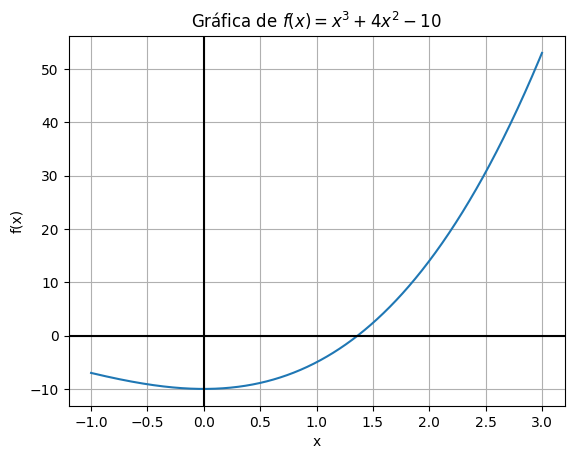

In [73]:
#Realizamos una gráfica de la función priorizando que se pueda observar que hay una raíz dentro del intervalo dado.
x=np.linspace(-1,3,1000)
y=funcion(x)
plt.plot(x,y)
plt.axhline(0,color="black")
plt.axvline(0,color="black")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title(r"Gráfica de $f(x)=x^3+4x^2-10$")
plt.grid()
plt.show()

In [80]:
#Ingresamos los datos de entrada.
a = 1
b = 2

#Guardamos los datos de entrada.
a0 = a
b0 = b

#Guardamos los valores iniciales del error y número de iteraciones.
tol = 0.00001
nmax = 20
error = np.abs(b-a)
niter = 0

In [81]:
#Evaluando el valor medio.
m = a+(b-a)/2

#Evaluando la función en los puntos.
fa = funcion(a)
fb = funcion(b)
fm = funcion(m)

#Lista para una tabla de resultados.
resultados = []

#Realizamos un bucle donde comparamos los signos obtenidos y con el cual obtendremos los valores aproximados a la raíz.
while error > tol and niter < nmax:

    #Guardamos los valores de la iteración actual
    resultados.append({"Iteración": niter, "a": a, "f(a)": fa, "b": b, "f(b)": fb, "m": m, "f(m)": fm, "Error": error})

    #Comparamos los signos
    if np.sign(fa) == np.sign(fm):
        a = m
        fa = funcion(a)
    else:
        b = m
        fb = funcion(b)

    m = a + (b - a) / 2
    fm = funcion(m)
    error = abs(b - a)
    niter += 1

#Guardamos la última iteración
resultados.append({"Iteración": niter, "a": a, "f(a)": fa, "b": b, "f(b)": fb, "m": m, "f(m)": fm, "Error": error})

# Creamos una tabla de resultados
tabla = pd.DataFrame(resultados)

display(tabla.round(6))

print("La raíz de la función dada en el intervalo ""[{0:6.4f}, {1:6.4f}] es {2:6.4f}".format(a0, b0, m))


,Iteración,a,f(a),b,f(b),m,f(m),Error
0,0,1.000000,-5.000000,2.000000,14.000000,1.500000,2.375000,1.000000
1,1,1.000000,-5.000000,1.500000,2.375000,1.250000,-1.796875,0.500000
2,2,1.250000,-1.796875,1.500000,2.375000,1.375000,0.162109,0.250000
3,3,1.250000,-1.796875,1.375000,0.162109,1.312500,-0.848389,0.125000
4,4,1.312500,-0.848389,1.375000,0.162109,1.343750,-0.350983,0.062500
5,5,1.343750,-0.350983,1.375000,0.162109,1.359375,-0.096409,0.031250
6,6,1.359375,-0.096409,1.375000,0.162109,1.367188,0.032356,0.015625
7,7,1.359375,-0.096409,1.367188,0.032356,1.363281,-0.032150,0.007812
8,8,1.363281,-0.032150,1.367188,0.032356,1.365234,0.000072,0.003906
9,9,1.363281,-0.032150,1.365234,0.000072,1.364258,-0.016047,0.001953


La raíz de la función dada en el intervalo [1.0000, 2.0000] es 1.3652
